In [1]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi

In [2]:
api = KaggleApi()
api.authenticate()

print("Usuário autenticado!")

Usuário autenticado!


In [3]:
# Download do dataset
DATASET_PATH = './data/blood-cell-images'

if os.path.exists(DATASET_PATH):
    print(f"Arquivos já presentes no disco. -> {DATASET_PATH}")
else:
    api.dataset_download_files(
        'sumithsingh/blood-cell-images-for-cancer-detection',
        path=DATASET_PATH,
        unzip=True
    )
    print(f"Arquivos baixados e descompactados. -> {DATASET_PATH}") if os.path.exists(DATASET_PATH) else print("Erro durante o download dos dados.")

Arquivos já presentes no disco. -> ./data/blood-cell-images


Na célula abaixo podemos observar que o dataset está equilibrado uma vez que temos o mesmo número de imagens para cada uma das classes. 

A partir disso, podemos dizer que temos um dataset estratificado.

In [4]:
LABELS = [d for d in os.listdir(DATASET_PATH)]

for label in LABELS:
    print(f"{label}: {len(os.listdir(os.path.join(DATASET_PATH, label)))} imagens")

monocyte: 1000 imagens
myeloblast: 1000 imagens
erythroblast: 1000 imagens
seg_neutrophil: 1000 imagens
basophil: 1000 imagens


* **Distribuição de Dimensões**: Precisamos checar qual será a resolução de entrada e, se necessário, a estratégia de redimensionamento.

[(360, 363), (366, 369), (360, 363), (360, 363), (360, 363)]


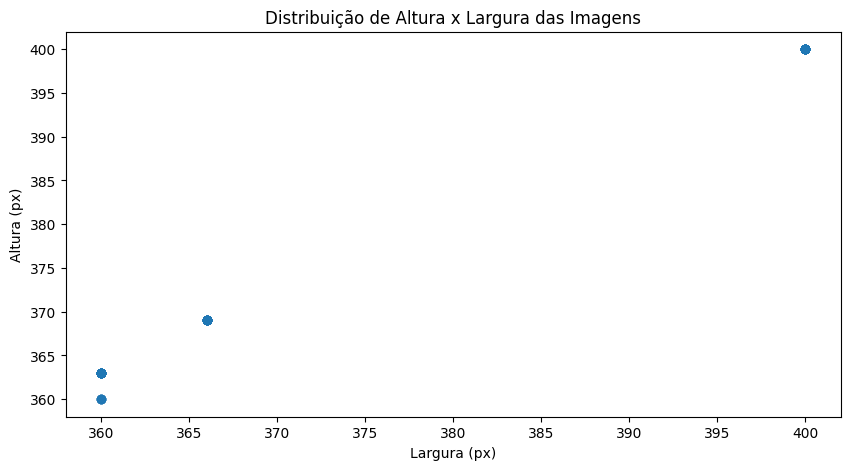

In [5]:
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

dimensoes = []

for label_dir in os.listdir(DATASET_PATH):
    imgs_dir = os.path.join(DATASET_PATH, label_dir)
    if not os.path.isdir(imgs_dir):
        print(f"Diretório {imgs_dir} não encontrado.")
        continue
    for img_name in os.listdir(imgs_dir):
        img_path = os.path.join(imgs_dir, img_name)
        try:
            img = cv2.imread(img_path)
            h, w, _ = img.shape
            dimensoes.append((w, h))
        except Exception as e:
            print(f"Erro ao ler {img_path}: {e}")

print(dimensoes[:5]) # 5 primeiras linhas.

dimensoes = np.array(dimensoes)

plt.figure(figsize=(10, 5))
plt.scatter(dimensoes[:, 0], dimensoes[:, 1], alpha=0.1)
plt.title('Distribuição de Altura x Largura das Imagens')
plt.xlabel('Largura (px)')
plt.ylabel('Altura (px)')
plt.show()

Vamos extrair a média das alturas e das larguras, para termos um parâmetro do tamanho geral das imagens.

Poderíamos plotar um barplot com o seguinte código, mas estamos interessados apenas nos valores:
```Python
# Barplot
plt.bar([f'Altura (h)\n {media_h}', f'Largura (w)\n {media_w}'], [media_h, media_w], color=['blue', 'red'])
plt.title("Média de Altura e Largura de todas as Imagens")
plt.ylabel("px")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()
```


In [6]:
# Cálculo das médias
media_h = np.mean(dimensoes[:, 0]) # Alturas
media_w = np.mean(dimensoes[:, 1]) # Larguras

print(f"A média de h x w entre todas as imagens é: ({media_h} x {media_w})")

A média de h x w entre todas as imagens é: (376.096 x 377.8762)


Iremos sortear imagens aleatórias e redimensiná-las (apenas para visualização) para o tamanho encontrado na média das imagens e com isso, poderemos identificar se as imagens que são menores ou maiores terão perda de qualidade considerável.

In [37]:
import random
from PIL import Image

# Amostra aleatória por classe
def plot_random_imgs(height=None, width=None):
    if height and width:
            print(f"Imagens serão redimensionadas para: ({height}x{height} px)")
    else:
        print("Imagens sem redimensionamento")
    
    plt.figure(figsize=(15, 4))

    for i, label in enumerate(LABELS):
        # Pegando uma imagem aleatória
        img_name = random.choice(os.listdir(os.path.join(DATASET_PATH, label)))
        img_path = os.path.join(DATASET_PATH, label, img_name)

        # Exibe a imagem redimensionada, se especificado.
        if height and width:
            img = Image.open(img_path).resize((height, width))
        else:
            # Imagem sem redimensionamento
            img = Image.open(img_path)
            

        plt.subplot(1, len(LABELS), i+1)
        plt.title(f"({img.size[0]}x{img.size[1]} px) \n {label}/{img_name}")
        plt.imshow(img)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Imagens serão redimensionadas para: (376x376 px)


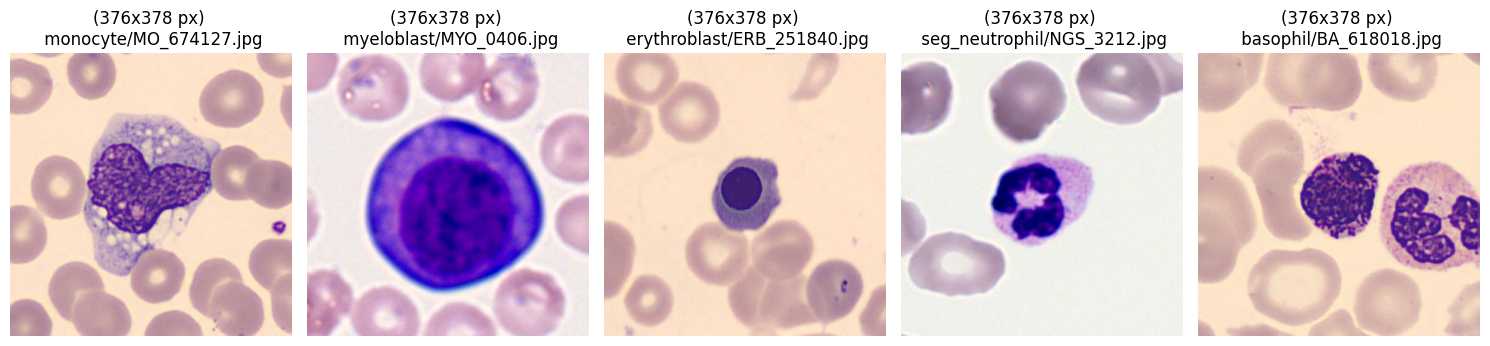

In [47]:
# As imagens só podem ser redimensionadas para números inteiros.
# Iremos arrendondar para o inteiro mais próximo da média
media_h = np.round(media_h).astype(int)
media_w = np.round(media_w).astype(int)
plot_random_imgs(media_h, media_w)